In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, LinearSegmentedColormap
from matplotlib.collections import LineCollection
import scipy.signal as signal
from scipy.optimize import curve_fit

In [ ]:
num_rc = 4                     
Aw = 0.05                      
RS = 0.001                     
RCT = 0.01                     
CDL = 0.0004                   

dt = 0.001                   
freqs = np.logspace(-1, 2, 40)  

omega_fit = 2 * np.pi * freqs

Z_warburg_ideal = Aw / np.sqrt(1j * omega_fit)
Z_cdl = 1/(CDL*1j*omega_fit)
Z_parallel = (Z_cdl*(RCT + Z_warburg_ideal)) / ((RCT + Z_warburg_ideal) + Z_cdl)
Z_randles = Z_parallel + RS

# where Warburg vs Rct vs Cdl actually take over
f_cross_warburg = (Aw / RCT)**2 / (2 * np.pi)
f_cross_bypass = (1 / (RCT * CDL)) / (2 * np.pi)

print(f"Warburg dominates its branch below ~{f_cross_warburg:.2f} Hz")
print(f"Rct+Warburg branch is increasingly bypassed by Cdl above ~{f_cross_bypass:.2f} Hz")

def rc_ladder_impedance(omega, *params):
    n_rc = len(params) // 2  # works for any n
    R = np.array(params[:n_rc])
    C = np.array(params[n_rc:])
    Z = np.zeros(len(omega), dtype=complex)
    for R_i, C_i in zip(R, C):
        Z_cdl = 1 / (1j * omega * C_i)
        Z += (R_i * Z_cdl) / (R_i + Z_cdl)
    return Z

def _rc_ladder_stacked(omega, *params):
    # curve_fit wants real numbers, not complex
    Z = rc_ladder_impedance(omega, *params)
    return np.concatenate([Z.real, Z.imag])

target_stacked = np.concatenate([Z_warburg_ideal.real, Z_warburg_ideal.imag])
n_points = len(target_stacked)

# same idea but scored against the full Randles circuit instead of Warburg alone
target_randles_stacked = np.concatenate([Z_randles.real, Z_randles.imag])

n_range = range(2, 9)
rmse_list = []
bic_list = []
rmse_randles_list = []
bic_randles_list = []

for n in n_range:
    tau_guess = np.logspace(-2, 1, n)
    R_guess = Aw * np.sqrt(tau_guess)
    C_guess = tau_guess / R_guess
    p0 = np.concatenate([R_guess, C_guess])

    popt_n, _ = curve_fit(_rc_ladder_stacked, omega_fit, target_stacked, p0=p0, bounds=(0, np.inf), maxfev=20000)
    R_n = popt_n[:n]
    C_n = popt_n[n:]

    tau_n = R_n * C_n
    print(f"n={n}: time constants (s) = {np.round(tau_n, 4)}")

    Z_fit_n = rc_ladder_impedance(omega_fit, *popt_n)
    rmse_n = np.sqrt(np.mean(np.abs(Z_fit_n - Z_warburg_ideal)**2))

    residuals = _rc_ladder_stacked(omega_fit, *popt_n) - target_stacked
    mse_n = np.mean(residuals**2)
    num_params = 2 * n
    bic_n = n_points * np.log(mse_n) + num_params * np.log(n_points)

    rmse_list.append(rmse_n)
    bic_list.append(bic_n)

    # embed the same fitted ladder into the full Randles circuit and rescore
    Z_cdl_n = 1 / (CDL * 1j * omega_fit)
    Z_parallel_n = (Z_cdl_n * (RCT + Z_fit_n)) / ((RCT + Z_fit_n) + Z_cdl_n)
    Z_randles_fit_n = Z_parallel_n + RS

    rmse_randles_n = np.sqrt(np.mean(np.abs(Z_randles_fit_n - Z_randles)**2))

    randles_fit_stacked_n = np.concatenate([Z_randles_fit_n.real, Z_randles_fit_n.imag])
    residuals_randles_n = randles_fit_stacked_n - target_randles_stacked
    mse_randles_n = np.mean(residuals_randles_n**2)
    bic_randles_n = n_points * np.log(mse_randles_n) + num_params * np.log(n_points)

    rmse_randles_list.append(rmse_randles_n)
    bic_randles_list.append(bic_randles_n)

    if n == num_rc:
        popt, R_arr, C_arr, tau_arr = popt_n, R_n, C_n, tau_n

fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

ax1.plot(list(n_range), rmse_list, 'b-o', label='RMSE')
ax2.plot(list(n_range), bic_list, 'r-s', label='BIC')

ax1.set_xlabel('Number of RC circuits (n)')
ax1.set_ylabel('RMSE (Ohms)', color='b')
ax2.set_ylabel('BIC', color='r')
ax1.tick_params(axis='y', labelcolor='b')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('RMSE and BIC vs Number of RC Circuits')
fig.tight_layout()
plt.show()

print(f"Fit {num_rc} RC circuits in series to match the ideal Warburg impedance (Aw={Aw}).")
print(f"Resistors (Ohms): {np.round(R_arr, 4)}")
print(f"Capacitors (Farads): {np.round(C_arr, 3)}")

In [ ]:
def full_randles_stacked(omega, Rs, Rct, Cdl, *ladder_params):
    n = len(ladder_params) // 2
    R = np.array(ladder_params[:n])
    C = np.array(ladder_params[n:])
    Zladder = np.zeros(len(omega), dtype=complex)
    for Ri, Ci in zip(R, C):
        Zc = 1 / (1j * omega * Ci)
        Zladder += (Ri * Zc) / (Ri + Zc)
    Zcdl = 1 / (Cdl * 1j * omega)
    Zpar = (Zcdl * (Rct + Zladder)) / ((Rct + Zladder) + Zcdl)
    Ztot = Rs + Zpar
    return np.concatenate([Ztot.real, Ztot.imag])

# fits Rs/Rct/Cdl along with the ladder instead of holding them fixed.
# bounded to +/-2x the assumed values -- unbounded, this doesn't converge at
# all (Rs/Rct/Cdl drift to non-physical values since the ladder can partly
# fake what they do)
n_range_joint = range(2, 21)
rmse_joint_list = []
bic_joint_list = []

for n in n_range_joint:
    tau0 = np.logspace(-2, 1, n)
    R0 = Aw * np.sqrt(tau0)
    C0 = tau0 / R0
    p0 = np.concatenate([[RS, RCT, CDL], R0, C0])
    lo = [RS*0.5, RCT*0.5, CDL*0.5] + [0]*(2*n)
    hi = [RS*2.0, RCT*2.0, CDL*2.0] + [np.inf]*(2*n)

    popt_joint, _ = curve_fit(full_randles_stacked, omega_fit, target_randles_stacked,
                               p0=p0, bounds=(lo, hi), maxfev=60000)
    fit_stacked = full_randles_stacked(omega_fit, *popt_joint)
    resid = fit_stacked - target_randles_stacked
    mse = np.mean(resid**2)
    rmse_joint_list.append(np.sqrt(mse))
    k = 2*n + 3
    bic_joint_list.append(n_points * np.log(mse) + k * np.log(n_points))

In [ ]:
# Rs/Rct/Cdl fit jointly with the ladder (bounded), instead of held fixed
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

ax1.plot(list(n_range_joint), rmse_joint_list, 'b-o', label='RMSE (joint fit)')
ax2.plot(list(n_range_joint), bic_joint_list, 'r-s', label='BIC (joint fit)')

ax1.set_xlabel('Number of RC circuits (n)')
ax1.set_ylabel('RMSE (Ohms)', color='b')
ax2.set_ylabel('BIC', color='r')
ax1.tick_params(axis='y', labelcolor='b')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('RMSE and BIC vs Number of RC Circuits (Rs/Rct/Cdl fit jointly with ladder)')
fig.tight_layout()
plt.show()

In [ ]:
# Nyquist plot for the full Randles shell (Rs/Rct/Cdl assumed, not fitted)
freqs_display = np.logspace(np.log10(f_cross_warburg / 4), np.log10(f_cross_bypass * 20), 500)
omega_display = 2 * np.pi * freqs_display

Z_warburg_ideal_display = Aw / np.sqrt(1j * omega_display)
Z_cdl_display = 1 / (CDL * 1j * omega_display)
Z_parallel_display = (Z_cdl_display * (RCT + Z_warburg_ideal_display)) / ((RCT + Z_warburg_ideal_display) + Z_cdl_display)
Z_randles_display = Z_parallel_display + RS

# fitted N=4 ladder standing in for Warburg, only over the band it was actually fit on
freqs_fit_band = np.logspace(-1, 2, 300)
omega_fit_band = 2 * np.pi * freqs_fit_band
Z_cdl_fit_band = 1 / (CDL * 1j * omega_fit_band)
Z_ladder_fit_band = rc_ladder_impedance(omega_fit_band, *popt)
Z_parallel_fit_band = (Z_cdl_fit_band * (RCT + Z_ladder_fit_band)) / ((RCT + Z_ladder_fit_band) + Z_cdl_fit_band)
Z_randles_fit_band = Z_parallel_fit_band + RS

# truncated so the line doesn't fade to white at low frequency
blues_visible = LinearSegmentedColormap.from_list('Blues_visible', plt.cm.Blues(np.linspace(0.35, 1.0, 256)))

fig, ax = plt.subplots(figsize=(8, 6))

points = np.array([Z_randles_display.real, -Z_randles_display.imag]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap=blues_visible, norm=LogNorm(), linewidths=4, zorder=2)
lc.set_array(freqs_display[:-1])
ax.add_collection(lc)
ax.autoscale()

ax.plot(Z_randles_fit_band.real, -Z_randles_fit_band.imag, color='#e34948', linestyle='--',
        linewidth=3, zorder=3, label='Fitted RC-ladder (N=4), 0.1-100 Hz only')

cbar = fig.colorbar(lc, ax=ax)
cbar.set_label('Frequency (Hz)')
ax.set_xlabel('Z real (Ohms)')
ax.set_ylabel('-Z imaginary (Ohms)')
ax.set_title('Randles Nyquist Plot: Ideal vs Fitted Warburg')
ax.axis('equal')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
Z_fit_optimal = rc_ladder_impedance(omega_fit, *popt)
error_pct = (np.abs(Z_warburg_ideal - Z_fit_optimal) / np.abs(Z_warburg_ideal)) * 100

plt.figure(figsize=(8, 5))
plt.semilogx(freqs, error_pct, 'b-o', markersize=4)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude Error (%)')
plt.title(f'Approximation Error vs Frequency (n={num_rc})')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
def model_zoh(R_arr, C_arr, I_signal, dt):
    n = len(I_signal)
    num_rc = len(R_arr)

    V_c = np.zeros((num_rc, n))
    V_tot = np.zeros(n)

    alpha = np.exp(-dt / (R_arr * C_arr))

    for k in range(1, n):
        V_c[:, k] = alpha * V_c[:, k-1] + (1 - alpha) * I_signal[k] * R_arr
        V_tot[k] = np.sum(V_c[:, k])
    return V_tot

def model_euler(R_arr, C_arr, I_signal, dt):
    n = len(I_signal)
    num_rc = len(R_arr)
    V_c = np.zeros((num_rc, n))
    V_tot = np.zeros(n)

    for k in range(1, n):
        dVc = (I_signal[k-1] - V_c[:, k-1] / R_arr) / C_arr
        V_c[:, k] = V_c[:, k-1] + dt * dVc
        V_tot[k] = np.sum(V_c[:, k])
    return V_tot

def model_rk4(R_arr, C_arr, I_signal, dt):
    # RK4 needs the current at t, t+dt/2, and t+dt, but we only have samples
    # at t and t+dt, so the midpoint is just linearly interpolated between them
    n = len(I_signal)
    num_rc = len(R_arr)
    V_c = np.zeros((num_rc, n))
    V_tot = np.zeros(n)

    def dVc(Vc, I, R, C):
        return (I - Vc / R) / C

    for k in range(1, n):
        I_prev = I_signal[k-1]
        I_next = I_signal[k]
        I_mid = 0.5 * (I_prev + I_next)

        k1 = dVc(V_c[:, k-1], I_prev, R_arr, C_arr)
        k2 = dVc(V_c[:, k-1] + dt/2 * k1, I_mid, R_arr, C_arr)
        k3 = dVc(V_c[:, k-1] + dt/2 * k2, I_mid, R_arr, C_arr)
        k4 = dVc(V_c[:, k-1] + dt * k3, I_next, R_arr, C_arr)

        V_c[:, k] = V_c[:, k-1] + dt/6 * (k1 + 2*k2 + 2*k3 + k4)
        V_tot[k] = np.sum(V_c[:, k])
    return V_tot

In [7]:
Z_real_zoh, Z_imag_zoh = [], []
Z_real_rk4, Z_imag_rk4 = [], []
Z_real_euler, Z_imag_euler = [], []

for f in freqs:
    # Warmup uses the slowest RC time constant in the fitted ladder
    t_warmup = 3 * np.max(tau_arr)
    t_signal = 10 / f         
    
    n_warmup = int(t_warmup / dt)
    n_signal = int(t_signal / dt)
    
    n_total = n_warmup + n_signal
    t_full = np.arange(n_total) * dt
    
    omega = 2 * np.pi * f
    I_full = np.sin(omega * t_full)
    
    def extract_Z(V_sweep, I_sweep, f):
        V_clean = V_sweep[n_warmup:]
        I_clean = I_sweep[n_warmup:]
        N = len(V_clean)
        
        V_fft = np.fft.fft(V_clean)
        I_fft = np.fft.fft(I_clean)
        freqs_fft = np.fft.fftfreq(N, dt) 
        
        idx = np.argmin(np.abs(freqs_fft - f))
        Z = V_fft[idx] / I_fft[idx]
        return Z.real, -Z.imag

    V_z = model_zoh(R_arr, C_arr, I_full, dt)
    zr, zi = extract_Z(V_z, I_full, f)
    Z_real_zoh.append(zr)
    Z_imag_zoh.append(zi)

    V_r = model_rk4(R_arr, C_arr, I_full, dt)
    zr, zi = extract_Z(V_r, I_full, f)
    Z_real_rk4.append(zr)
    Z_imag_rk4.append(zi)

    V_eu = model_euler(R_arr, C_arr, I_full, dt)
    zr, zi = extract_Z(V_eu, I_full, f)
    Z_real_euler.append(zr)
    Z_imag_euler.append(zi)

In [ ]:
def freq_domain_rc_ladder(freqs, R_arr, C_arr):
    omega = 2 * np.pi * freqs
    Z_tot = np.zeros(len(freqs), dtype=complex)

    for R, C in zip(R_arr, C_arr):
        Z_cdl = 1 / (1j * omega * C)
        Z_tot += (R * Z_cdl) / (R + Z_cdl)
    return Z_tot

Z_freq = freq_domain_rc_ladder(freqs, R_arr, C_arr)

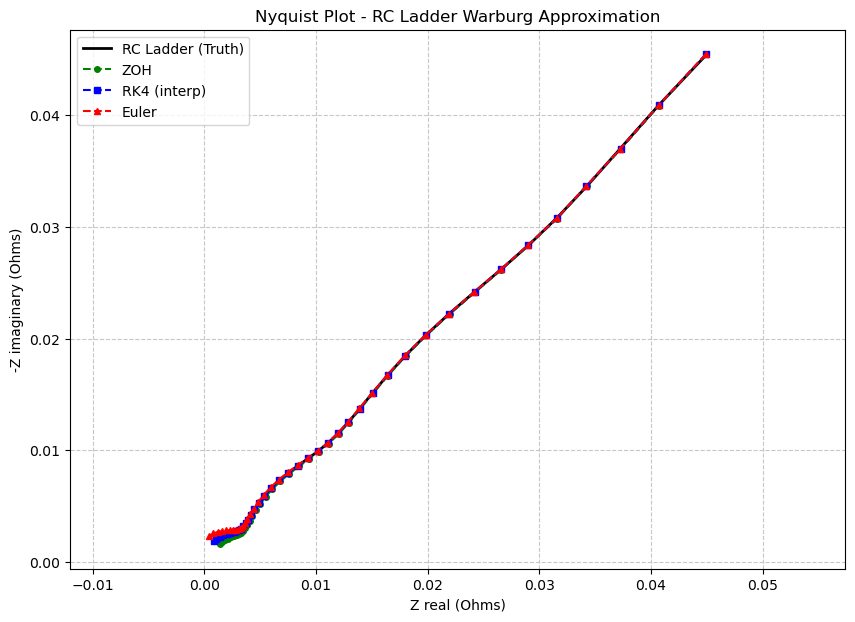

In [9]:
plt.figure(figsize=(10, 7))
plt.plot(Z_freq.real, -Z_freq.imag, 'k-', linewidth=2, label='RC Ladder (Truth)')
plt.plot(Z_real_zoh, Z_imag_zoh, 'g--o', markersize=4, label='ZOH')
plt.plot(Z_real_rk4, Z_imag_rk4, 'b--s', markersize=4, label='RK4 (interp)')
plt.plot(Z_real_euler, Z_imag_euler, 'r--^', markersize=4, label='Euler')
plt.xlabel('Z real (Ohms)')
plt.ylabel('-Z imaginary (Ohms)')
plt.title('Nyquist Plot - RC Ladder Warburg Approximation')
plt.axis('equal') 
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

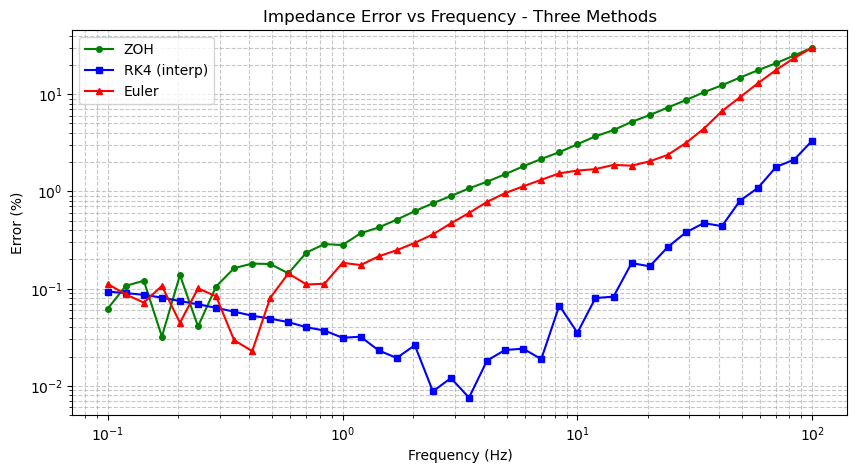

ZOH           : mean=4.630%  max=30.066%  (at 100.00 Hz)
RK4 (interp)  : mean=0.309%  max=3.321%  (at 100.00 Hz)
Euler         : mean=3.213%  max=30.015%  (at 100.00 Hz)


In [10]:
Z_zoh_arr = np.array(Z_real_zoh) - 1j * np.array(Z_imag_zoh)
Z_rk4_arr = np.array(Z_real_rk4) - 1j * np.array(Z_imag_rk4)
Z_euler_arr = np.array(Z_real_euler) - 1j * np.array(Z_imag_euler)

def error_pct(Z_sim, Z_ref):
    # How far off each method's impedance is from the true value, as a % of the true value
    return np.abs(Z_sim - Z_ref) / np.abs(Z_ref) * 100

plt.figure(figsize=(10, 5))
plt.loglog(freqs, error_pct(Z_zoh_arr, Z_freq), 'g-o', markersize=4, label='ZOH')
plt.loglog(freqs, error_pct(Z_rk4_arr, Z_freq), 'b-s', markersize=4, label='RK4 (interp)')
plt.loglog(freqs, error_pct(Z_euler_arr, Z_freq), 'r-^', markersize=4, label='Euler')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Error (%)')
plt.title('Impedance Error vs Frequency - Three Methods')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

for name, Z_arr in [('ZOH', Z_zoh_arr), ('RK4 (interp)', Z_rk4_arr), ('Euler', Z_euler_arr)]:
    e = error_pct(Z_arr, Z_freq)
    print(f"{name:14s}: mean={e.mean():.3f}%  max={e.max():.3f}%  (at {freqs[np.argmax(e)]:.2f} Hz)")